## Config

In [1]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from trino.dbapi import connect
from trino.auth import BasicAuthentication, OAuth2Authentication

TRINO_HOST = "turing-embedded-data-science-fte-mode.trino.galaxy.starburst.io"
TRINO_CATALOG = "trainline_data"


private_path = Path("private.json")

if private_path.exists():
    creds = json.loads(private_path.read_text())
    db_user = creds["email"]
    db_password = creds["password"]
    auth = BasicAuthentication(db_user, db_password)
else:
    db_user = os.getenv("db_user") or os.getenv("TRINO_USER")
    db_password = os.getenv("db_password") or os.getenv("TRINO_PASSWORD")

    if db_user and db_password:
        auth = BasicAuthentication(db_user, db_password)
    else:
        # Fall back to OAuth if no private.json / password creds are available
        db_user = db_user or os.getenv("EMAIL") or os.getenv("USER")
        auth = OAuth2Authentication()

conn = locals().get(
    "conn",
    connect(
        auth=auth,
        http_scheme="https",
        host=TRINO_HOST,
        port=443,
        user=db_user,
        catalog=TRINO_CATALOG,
    ),
)

## Table Comparisions - Marketing Orders Attribution NTS (GBP)

In [10]:
df_marketing_orders_attribution = pd.read_sql(
    """
    WITH unknown_channel_nts AS (
    SELECT
        DATE(activity_date) AS activity_date,
        SUM(IF(channel_0 = 'Unknown', net_sales_gbp, 0)) AS unknown_nts,
        SUM(net_sales_gbp) AS total_nts,
        SUM(IF(channel_0 = 'Unknown', net_sales_gbp, 0)) / SUM(net_sales_gbp) AS proportion_nts_unknown
    FROM de_dwh_lf.marketing_orders mo
    WHERE region = 'United Kingdom'
        AND DATE(activity_date) >= DATE'2025-01-05'
    GROUP BY 1
),

marketing_channel_nts AS (
    SELECT
        DATE(activity_date) AS activity_date,
        channel_0,
        channel_1,
        channel_2,
        SUM(net_sales_gbp) AS nts_gbp
    FROM de_dwh_lf.marketing_orders mo
    WHERE region = 'United Kingdom'
        AND DATE(activity_date) >= DATE'2025-01-05'
        AND channel_0 != 'Unknown'
    GROUP BY 1,2,3,4
)

SELECT
    mcn.activity_date,
    mcn.channel_0,
    mcn.channel_1,
    mcn.channel_2,
    mcn.nts_gbp,
    mcn.nts_gbp / (1 - ucn.proportion_nts_unknown) AS scaled_nts_gbp
FROM marketing_channel_nts mcn
JOIN unknown_channel_nts ucn
    ON mcn.activity_date = ucn.activity_date
WHERE
    (channel_0 = 'Web - Paid Social' AND channel_2 = 'Facebook')
ORDER BY 1,2""",
    conn)

df_marketing_orders_attribution

/var/folders/xc/5db63q_n4mn023lqftp12t_m0000gp/T/ipykernel_58063/3137899515.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_marketing_orders_attribution = pd.read_sql(


,activity_date,channel_0,channel_1,channel_2,nts_gbp,scaled_nts_gbp
0,2025-01-05,Web - Paid Social,Paid Social,Facebook,259195.484284,272829.693979
1,2025-01-06,Web - Paid Social,Paid Social,Facebook,361450.232558,381027.608649
2,2025-01-07,Web - Paid Social,Paid Social,Facebook,344021.105744,362260.697861
3,2025-01-08,Web - Paid Social,Paid Social,Facebook,311203.476696,327632.111916
4,2025-01-09,Web - Paid Social,Paid Social,Facebook,301666.579913,317059.665613
...,...,...,...,...,...,...
524,2026-06-13,Web - Paid Social,Paid Social,Facebook,517931.486632,541081.424330
525,2026-06-14,Web - Paid Social,Paid Social,Facebook,520345.315256,548545.516393
526,2026-06-15,Web - Paid Social,Paid Social,Facebook,793150.722251,844106.577336
527,2026-06-16,Web - Paid Social,Paid Social,Facebook,815770.785609,864266.387035


In [11]:
df_marketing_yield = pd.read_sql(
    """
SELECT
    DATE(activity_date) AS activity_date,
    channel_0,
    channel_1,
    channel_2,
    SUM(total_gross_sales_gbp) AS nts_gbp
FROM bi_dwh.marketing_yield
WHERE original_attribution = FALSE
  AND region = 'United Kingdom'
  AND DATE(activity_date) >= DATE '2025-01-05'
  AND (
        (channel_0 = 'Web - Paid Social' AND channel_2 = 'Facebook')
  )
GROUP BY 1,2,3,4
ORDER BY 1,2""",
    conn)
df_marketing_yield

/var/folders/xc/5db63q_n4mn023lqftp12t_m0000gp/T/ipykernel_58063/3971523421.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_marketing_yield = pd.read_sql(


,activity_date,channel_0,channel_1,channel_2,nts_gbp
0,2025-01-05,Web - Paid Social,Paid Social,Facebook,283252.884284
1,2025-01-06,Web - Paid Social,Paid Social,Facebook,386898.610259
2,2025-01-07,Web - Paid Social,Paid Social,Facebook,362469.282880
3,2025-01-08,Web - Paid Social,Paid Social,Facebook,327252.976696
4,2025-01-09,Web - Paid Social,Paid Social,Facebook,318422.653440
...,...,...,...,...,...
524,2026-06-13,Web - Paid Social,Paid Social,Facebook,525976.591162
525,2026-06-14,Web - Paid Social,Paid Social,Facebook,531990.671536
526,2026-06-15,Web - Paid Social,Paid Social,Facebook,804620.730008
527,2026-06-16,Web - Paid Social,Paid Social,Facebook,825379.496774


In [12]:
df_merged = df_marketing_orders_attribution.merge(
    df_marketing_yield,
    how="left",
    on=["activity_date", "channel_0", "channel_1", "channel_2"],
    suffixes=("_attribution", "_yield"),
).assign(
    difference=lambda x: x["nts_gbp_yield"] - x["nts_gbp_attribution"], 
    difference_percentage=lambda x: (x["nts_gbp_yield"] - x["nts_gbp_attribution"]) / x["nts_gbp_yield"] * 100
)
df_merged

,activity_date,channel_0,channel_1,channel_2,nts_gbp_attribution,scaled_nts_gbp,nts_gbp_yield,difference,difference_percentage
0,2025-01-05,Web - Paid Social,Paid Social,Facebook,259195.484284,272829.693979,283252.884284,24057.400000,8.493259
1,2025-01-06,Web - Paid Social,Paid Social,Facebook,361450.232558,381027.608649,386898.610259,25448.377701,6.577531
2,2025-01-07,Web - Paid Social,Paid Social,Facebook,344021.105744,362260.697861,362469.282880,18448.177136,5.089584
3,2025-01-08,Web - Paid Social,Paid Social,Facebook,311203.476696,327632.111916,327252.976696,16049.500000,4.904310
4,2025-01-09,Web - Paid Social,Paid Social,Facebook,301666.579913,317059.665613,318422.653440,16756.073526,5.262212
...,...,...,...,...,...,...,...,...,...
524,2026-06-13,Web - Paid Social,Paid Social,Facebook,517931.486632,541081.424330,525976.591162,8045.104530,1.529556
525,2026-06-14,Web - Paid Social,Paid Social,Facebook,520345.315256,548545.516393,531990.671536,11645.356280,2.189015
526,2026-06-15,Web - Paid Social,Paid Social,Facebook,793150.722251,844106.577336,804620.730008,11470.007757,1.425517
527,2026-06-16,Web - Paid Social,Paid Social,Facebook,815770.785609,864266.387035,825379.496774,9608.711165,1.164157


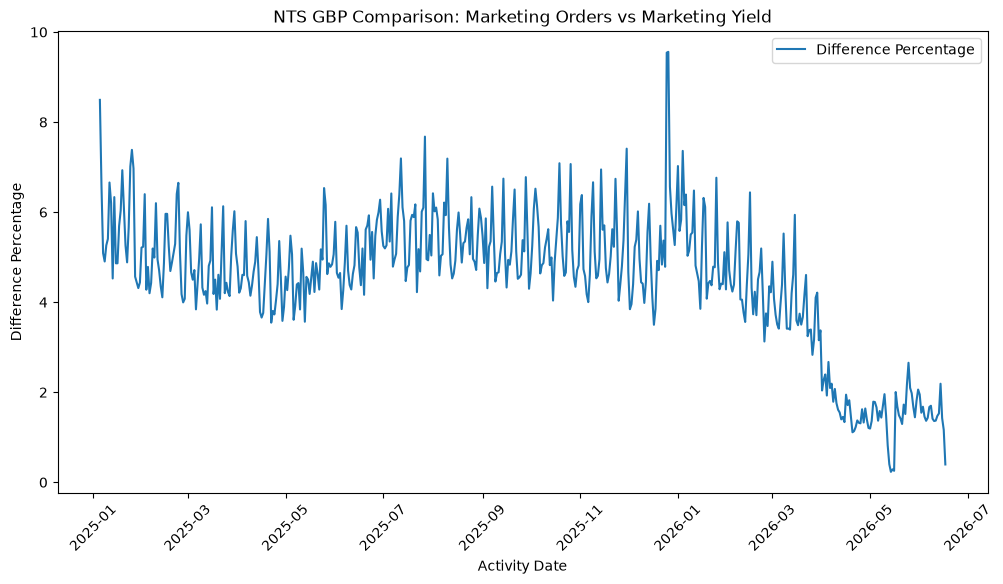

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(df_merged['activity_date'], df_merged['difference_percentage'], label='Difference Percentage', linestyle='-')
plt.title('NTS GBP Comparison: Marketing Orders vs Marketing Yield')
plt.xlabel('Activity Date')
plt.ylabel('Difference Percentage')
plt.xticks(rotation=45)
plt.legend()